
# 📊 **APE_012: Análisis Bivariado y Predicción: Correlación de Pearson y Modelo de Regresión Lineal Simple (OLS)**


---

### **GRUPO G**

#### 👥 **Integrantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera



## 📈 **Tarea 1: Análisis de Correlación de Pearson**

El coeficiente de correlación de Pearson ($r$) mide la dependencia lineal entre dos variables, oscilando entre $-1$ (correlación negativa perfecta) y $1$ (correlación positiva perfecta).

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

Abra un nuevo Jupyter Notebook llamado `APE_013_Regresion.ipynb`.
**Escenario:** Analizaremos la relación entre los "**Usuarios Concurrentes**" en un servidor ($X$) y el "**Consumo de Ancho de Banda en Mbps**" ($Y$).

--- Análisis de Correlación de Pearson ---
Coeficiente (r): 0.9603
Valor-p (Significancia): 3.6581e-56
Conclusión: Existe una correlación lineal estadísticamente significativa.


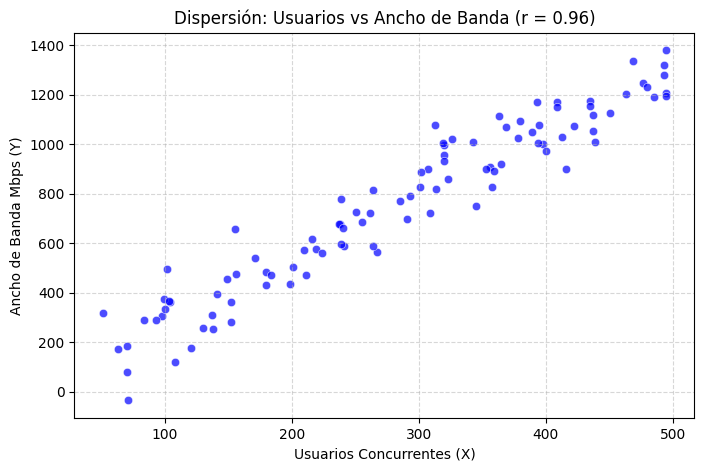

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Configuración y Generación de datos simulados (Relación positiva fuerte con ruido)
np.random.seed(42)
usuarios_X = np.random.randint(50, 500, size=100)

# Y = 2.5 * X + 50 + Ruido Aleatorio
ancho_banda_Y = 2.5 * usuarios_X + 50 + np.random.normal(0, 100, size=100)

# 2. Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor = pearsonr(usuarios_X, ancho_banda_Y)

print("--- Análisis de Correlación de Pearson ---")
print(f"Coeficiente (r): {coef_pearson:.4f}")
print(f"Valor-p (Significancia): {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusión: Existe una correlación lineal estadísticamente significativa.")
else:
    print("Conclusión: NO existe evidencia de correlación lineal significativa.")

# 3. Visualización: Diagrama de Dispersión (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, color='blue', alpha=0.7)

plt.title(f'Dispersión: Usuarios vs Ancho de Banda (r = {coef_pearson:.2f})')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 📉 **Tarea 2: Ajuste del Modelo de Regresión Lineal Simple (OLS)**

Si existe correlación, podemos modelar la relación mediante una línea recta:  
$\hat{y} = \beta_0 + \beta_1 x$, donde $\beta_0$ es el intercepto y $\beta_1$ la pendiente.

1. Utilizaremos statsmodels, ya que provee un resumen estadístico profundo al estilo de la econometría clásica.
2. Agregue y ejecute el siguiente código en su cuaderno:

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     1163.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.66e-56
Time:                        13:14:45   Log-Likelihood:                -597.28
No. Observations:                 100   AIC:                             1199.
Df Residuals:                      98   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.6745     23.385      1.226      0.2

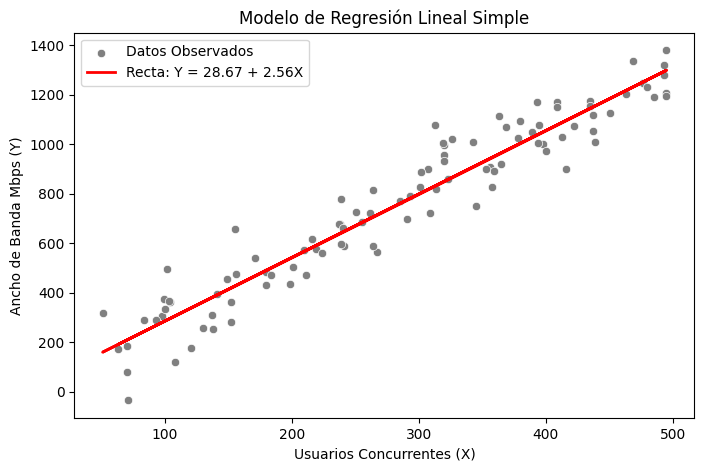

In [6]:
import statsmodels.api as sm

# Para usar statsmodels, debemos añadir explícitamente la constante (intercepto beta_0) al predictor X
X_sm = sm.add_constant(usuarios_X)
Y_sm = ancho_banda_Y

# Ajuste del modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_ols = sm.OLS(Y_sm, X_sm).fit()

# Impresión del resumen estadístico
print(modelo_ols.summary())

# Extracción de parámetros para graficar la recta
beta_0 = modelo_ols.params[0]
beta_1 = modelo_ols.params[1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, label='Datos Observados', color='gray')

# Dibujo de la recta de regresión
plt.plot(usuarios_X, beta_0 + beta_1 * usuarios_X, color='red', linewidth=2, label=f'Recta: Y = {beta_0:.2f} + {beta_1:.2f}X')
plt.title('Modelo de Regresión Lineal Simple')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.legend()
plt.show()

## 🎯 **Tarea 3: Hito del Proyecto - Predicción en el Dataset Regional (ABP)**

1. Importe su dataset regional mediante pandas.
2. Identifique una variable independiente/predictora ($X$) y una variable dependiente/respuesta ($Y$). *Ejemplo: X = Precipitación, Y = Producción Agrícola.*
3. Aplique el flujo de las Tareas 1 y 2: Calcule $r$, ajuste el modelo OLS e imprima el summary().
4. **Predicción:** Usando los coeficientes obtenidos ($\beta_0, \beta_1$), calcule manualmente mediante código Python el valor esperado de $Y$ para un valor crítico de $X$ que **no** exista en su dataset original (pronóstico).
5. Interprete desde la perspectiva del negocio el valor del **R-squared ($R^2$)** que le arrojó el resumen estadístico.

ANÁLISIS DE CORRELACIÓN DE PEARSON
Coeficiente de Pearson (r): 0.9336
Valor-p: 1.2732e-07
Conclusión: Existe una correlación lineal significativa.

RESUMEN DEL MODELO OLS
                            OLS Regression Results                            
Dep. Variable:     Sin_Alcantarillado   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     95.11
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.27e-07
Time:                        13:18:05   Log-Likelihood:                -129.48
No. Observations:                  16   AIC:                             263.0
Df Residuals:                      14   BIC:                             264.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err       

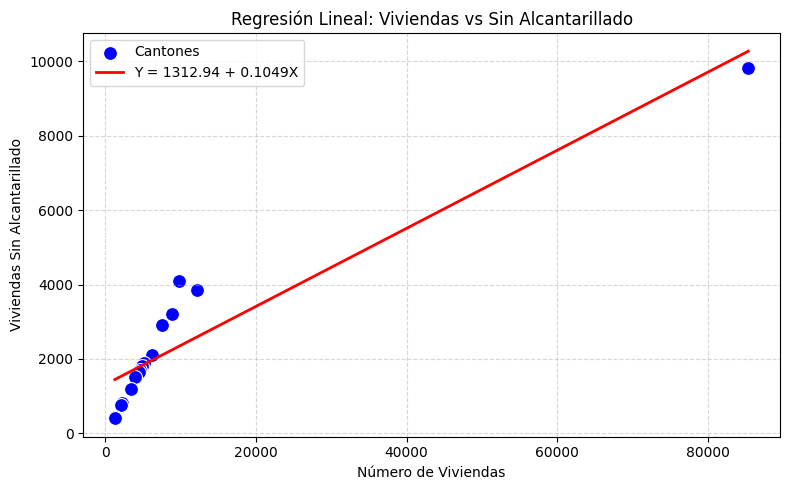

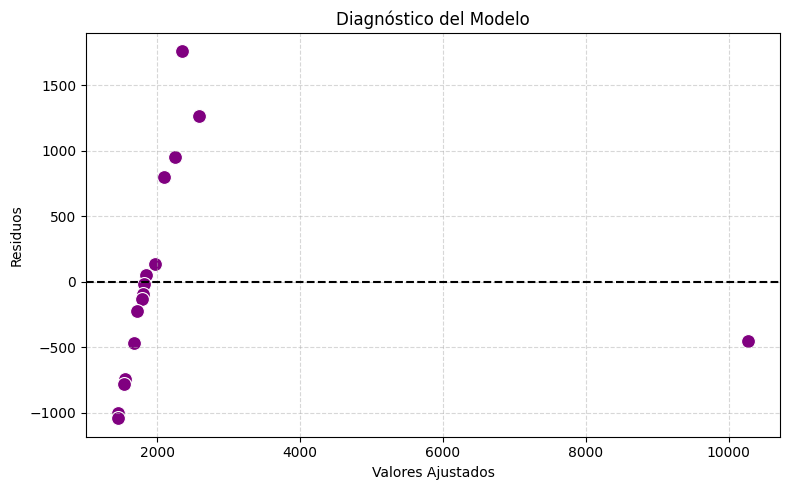

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr, shapiro

# 1. Importar el dataset regional

df = pd.read_csv('/content/datos_loja2 (1).csv')

# 2. Variable Predictora (X) y Variable Respuesta (Y)

nombre_variable_X = "Viviendas"
nombre_variable_Y = "Sin_Alcantarillado"

X = df[nombre_variable_X]
Y = df[nombre_variable_Y]

# 3. CORRELACIÓN DE PEARSON

r, p = pearsonr(X, Y)

print("==================================================")
print("ANÁLISIS DE CORRELACIÓN DE PEARSON")
print("==================================================")
print(f"Coeficiente de Pearson (r): {r:.4f}")
print(f"Valor-p: {p:.4e}")

if p < 0.05:
    print("Conclusión: Existe una correlación lineal significativa.")
else:
    print("Conclusión: No existe una correlación lineal significativa.")

# 4. MODELO DE REGRESIÓN LINEAL (OLS)

X_const = sm.add_constant(X)

modelo = sm.OLS(Y, X_const).fit()

print("\n==================================================")
print("RESUMEN DEL MODELO OLS")
print("==================================================")
print(modelo.summary())

# 5. INTERPRETACIÓN DEL R²

r2 = modelo.rsquared

print("\n==================================================")
print("INTERPRETACIÓN DEL R²")
print("==================================================")

print(f"R² = {r2:.4f}")

print(f"\nEl modelo explica aproximadamente el {r2*100:.2f}% "
      f"de la variación de '{nombre_variable_Y}' mediante "
      f"la variable '{nombre_variable_X}'.")

print(f"El {100-r2*100:.2f}% restante se explica por otros factores "
      "que no forman parte del modelo.")

if r2 >= 0.80:
    print("\nInterpretación:")
    print("El modelo presenta un ajuste muy bueno y una alta capacidad predictiva.")
elif r2 >= 0.60:
    print("\nInterpretación:")
    print("El modelo presenta un ajuste aceptable para realizar predicciones.")
else:
    print("\nInterpretación:")
    print("El modelo tiene un ajuste bajo y se recomienda incluir más variables.")

# 6. PREDICCIÓN

beta0 = modelo.params.iloc[0]
beta1 = modelo.params.iloc[1]

valor_critico = 20000

prediccion = beta0 + beta1 * valor_critico

print("\n==================================================")
print("PREDICCIÓN")
print("==================================================")

print(f"Para un cantón con {valor_critico:,} viviendas:")

print(f"El número esperado de viviendas sin alcantarillado es: "
      f"{prediccion:.2f}")

# 7. NORMALIDAD DE LOS RESIDUOS

residuos = modelo.resid

estadistico, p_shapiro = shapiro(residuos)

print("\n==================================================")
print("PRUEBA DE SHAPIRO-WILK")
print("==================================================")

print(f"Valor-p = {p_shapiro:.4f}")

if p_shapiro > 0.05:
    print("Los residuos siguen una distribución normal.")
else:
    print("Los residuos NO siguen una distribución normal.")

# 8. GRÁFICO DE DISPERSIÓN + RECTA DE REGRESIÓN

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X,
    y=Y,
    color="blue",
    s=100,
    label="Cantones"
)

x_linea = np.linspace(X.min(), X.max(), 100)

plt.plot(
    x_linea,
    beta0 + beta1*x_linea,
    color="red",
    linewidth=2,
    label=f"Y = {beta0:.2f} + {beta1:.4f}X"
)

plt.title("Regresión Lineal: Viviendas vs Sin Alcantarillado")

plt.xlabel("Número de Viviendas")

plt.ylabel("Viviendas Sin Alcantarillado")

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()

# 9. DIAGNÓSTICO DE RESIDUOS

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=modelo.fittedvalues,
    y=residuos,
    color="purple",
    s=100
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Diagnóstico del Modelo")

plt.xlabel("Valores Ajustados")

plt.ylabel("Residuos")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

 ## 📊**Interpretación del R² desde la perspectiva del negocio**
El modelo obtuvo un: R² = 0.8717 (87.17%)

El modelo explica aproximadamente el 87.17% de la variación del número de viviendas sin alcantarillado utilizando como variable predictora el número total de viviendas. Esto indica que existe una relación fuerte entre ambas variables y que el modelo posee una alta capacidad predictiva.

Desde la perspectiva de la planificación y la gestión pública, este modelo puede utilizarse para estimar la demanda futura de infraestructura de alcantarillado, facilitando la planificación de inversiones, la asignación de recursos y la priorización de proyectos en cantones con crecimiento urbano. El 12.83% restante de la variación puede atribuirse a otros factores no incluidos en el modelo, como la inversión pública, la ubicación geográfica, el desarrollo urbano o las políticas municipales.

## 📝 **4. Preguntas de Control:**

---

* **Análisis de Sensibilidad:** **Basándose en su variable independiente ($X$) y dependiente ($Y$), ¿la pendiente ($\beta_1$) calculada tiene sentido lógico con el fenómeno de su región? Justifique cuantitativamente el impacto de un incremento unitario de $X$ en $Y$.**

  Sí. La pendiente obtenida fue β₁ = 0.1049, lo que significa que por cada vivienda adicional en un cantón de la provincia de Loja, el modelo estima un incremento promedio de 0.1049 viviendas sin alcantarillado. Este resultado tiene sentido lógico, ya que al aumentar el número de viviendas también aumenta la demanda de infraestructura sanitaria y, si la cobertura de alcantarillado no crece al mismo ritmo, es esperable que aumente el número de viviendas sin este servicio. Por ejemplo, un incremento de 1000 viviendas implicaría aproximadamente 105 viviendas adicionales sin alcantarillado (1000 × 0.1049 ≈ 104.9).

---

1. **Inferencia y Significancia:** **En el resumen de statsmodels, ¿qué indica el P-value (Prob>|t|) del predictor respecto a la Hipótesis Nula ($H_0$)? ¿Qué riesgo corre su modelo si este valor supera el umbral de 0.05?**


    El P-value (Prob>|t|) del predictor indica la probabilidad de obtener el efecto observado suponiendo que la hipótesis nula (H₀: β₁ = 0) sea verdadera. En este modelo, el valor es 0.000, menor que 0.05, por lo que se rechaza la hipótesis nula y se concluye que la variable Viviendas influye significativamente sobre la cantidad de viviendas sin alcantarillado. Si el P-value fuera mayor que 0.05, no habría evidencia estadística suficiente para afirmar que el predictor tiene efecto, reduciendo la confianza en el modelo para explicar y realizar predicciones.

---

2. **Bondad de Ajuste vs. Relación Lineal:¿Cómo explica usted la diferencia conceptual entre el Coeficiente de Correlación ($r$) y el $R^2$? Si el $R^2$ es bajo (p.ej., < 0.5), ¿qué nos dice sobre la variabilidad de sus datos que el modelo lineal no está logrando capturar?**

    El coeficiente de correlación (r) mide la fuerza y la dirección de la relación lineal entre dos variables, mientras que el R² indica qué porcentaje de la variabilidad de la variable dependiente es explicado por el modelo de regresión. En este estudio, r = 0.9336 muestra una relación positiva muy fuerte y R² = 0.8717 indica que el 87.17% de la variación de las viviendas sin alcantarillado es explicada por el número de viviendas. Si el R² fuera menor a 0.5, significaría que el modelo explica menos de la mitad de la variabilidad observada y que existen otros factores importantes que no están siendo considerados.
    
---

3. **Límites de la Predicción: ¿Qué riesgos de sesgo o error se introducen al realizar extrapolaciones fuera del dominio de los datos observados? Ilustre con un caso hipotético de su proyecto.**

    La extrapolación consiste en realizar predicciones para valores de la variable independiente que están fuera del rango observado en los datos. Esto puede producir estimaciones poco confiables, ya que la relación entre las variables podría cambiar. En este proyecto, por ejemplo, se realizó una predicción para un cantón hipotético con 20 000 viviendas. Si se intentara predecir para un cantón con 200 000 viviendas, el resultado podría ser poco realista porque el modelo fue construido con datos de cantones de la provincia de Loja, cuyos valores son considerablemente menores y pueden seguir un comportamiento diferente.

---

4. **Validación de Supuestos (ABI): Si en su diagnóstico de residuos observa un patrón no aleatorio (por ejemplo, forma de "U" o abanico), ¿por qué es inválido asumir que el modelo es lineal? ¿Qué alternativa sugeriría para ajustar mejor la relación entre $X$ y $Y$?**

    Si el gráfico de residuos presenta un patrón no aleatorio, como una forma de "U" o un abanico, significa que no se cumplen los supuestos de linealidad o de varianza constante del modelo. En ese caso, la regresión lineal no representa adecuadamente la relación entre las variables y las predicciones pueden ser menos confiables. Como alternativa, se podría utilizar una regresión polinómica, aplicar transformaciones a las variables (como logaritmos) o emplear un modelo no lineal que describa mejor el comportamiento de los datos.
